# Libraries for Google Colab:

In [ ]:
!pip install pandas numpy matplotlib scikit-learn seaborn

# Data Preprocessing:

In [1]:
from __future__ import annotations
import csv
from datetime import datetime
from pathlib import Path
from typing import Iterable

INPUT_FILE = Path("APPLE_daily.csv")
OUTPUT_FILE = Path("APPLE_daily_reformed.csv")
START_DATE = datetime(2000, 1, 1)


def parse_row(row: list[str]) -> tuple[datetime, list[str]]:
    if len(row) != 7:
        raise ValueError(f"Expected 7 columns per row, got {len(row)}: {row}")

    date = datetime.strptime(row[0], "%Y-%m-%d")
    open_price = row[1]
    high_price = row[2]
    low_price = row[3]
    close_price = row[4]
    volume = row[5]
    adj_close = row[6]

    return date, [
        row[0],
        open_price,
        high_price,
        low_price,
        close_price,
        volume,
        adj_close,
    ]
def clean_rows(rows: Iterable[list[str]]) -> list[list[str]]:
    cleaned_rows: list[list[str]] = []

    for row in rows:
        date, normalized_row = parse_row(row)
        if date >= START_DATE:
            cleaned_rows.append(normalized_row)

    cleaned_rows.sort(key=lambda item: item[0])
    return cleaned_rows
def main() -> None:
    with INPUT_FILE.open(newline="", encoding="utf-8") as source:
        reader = csv.reader(source)
        header = next(reader)
        if len(header) != 7:
            raise ValueError(f"Expected 7 columns in header, got {len(header)}: {header}")

        cleaned_rows = clean_rows(list(reader))

    with OUTPUT_FILE.open("w", newline="", encoding="utf-8") as target:
        writer = csv.writer(target)
        writer.writerow(["Date", "Open", "High", "Low", "Close", "Volume", "Adj Close"])
        writer.writerows(cleaned_rows)

    print(f"Wrote {len(cleaned_rows)} rows to {OUTPUT_FILE.name}")
main()

Wrote 6638 rows to APPLE_daily_reformed.csv


# Explaratory Data Analysis:

In this notebook, we create a lineplot and a heatmap to help us visualize our data (closing price and moving averages) and determine what features we should add/remove in the training of our models.

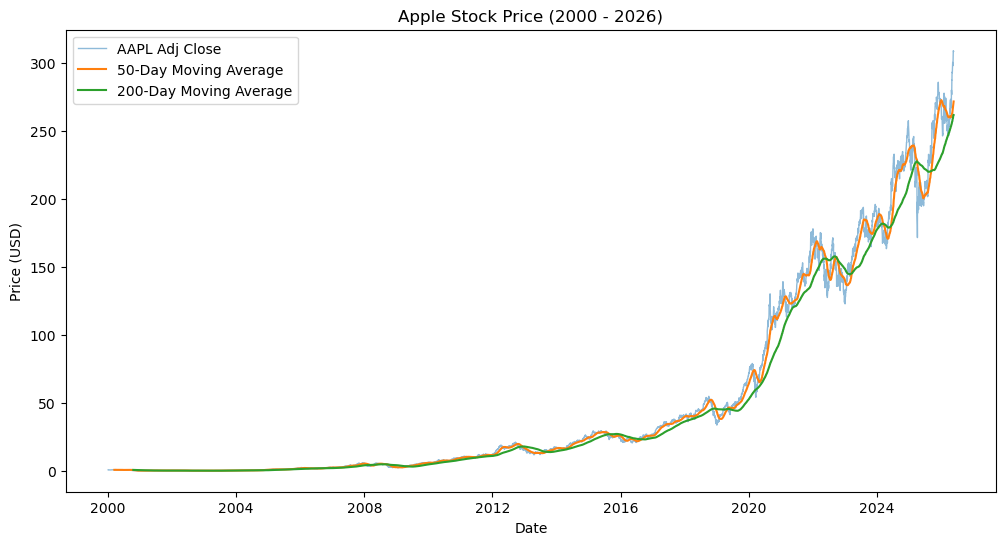

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('APPLE_daily_reformed.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df['SMA_50'] = df['Adj Close'].rolling(window=50).mean()
df['SMA_200'] = df['Adj Close'].rolling(window=200).mean()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Adj Close'], label='AAPL Adj Close', alpha=0.5, linewidth=1)
plt.plot(df.index, df['SMA_50'], label='50-Day Moving Average', linewidth=1.5)
plt.plot(df.index, df['SMA_200'], label='200-Day Moving Average', linewidth=1.5)

plt.title('Apple Stock Price (2000 - 2026)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

This lineplot represents the closing price for Apple stock from January 3, 2000 to May 26, 2026. In this plot, we show three lines: adjusted close for each day, 50 day simple moving average, and 200 day simple moving average. The adjusted close accounts for corporate actions such as stock splits and dividents. As such, using the adjusted closing price over closing price allows us to better understand the stock's true nature over time by providing a more accurate baseline for analysis across different periods. The moving average (50 days and 200 days) ensures that the impacts of random, short-term fluctuations on the stock price over a specified time frame are mitigated, allowing us to better visualize the trends and patterns in the data while minimizing the noise. We plan to incorporate the moving average instead of solely relying on the daily closing prices for the training of our models, both in the linear regression and random forest models.

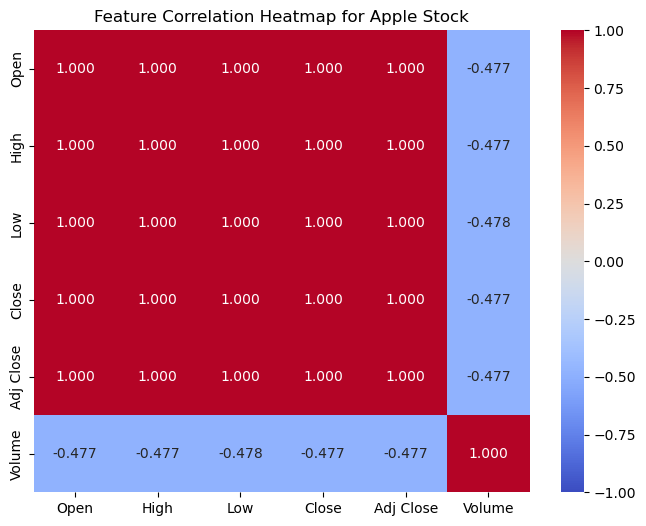

In [2]:
import seaborn as sns

numerical_features = df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']]

corr_matrix = numerical_features.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap for Apple Stock')
plt.show()

The correlation heatmap represents the relationship between the features in our data. Analyzing the heatmap reveals that the opening price, high, low, close, and adjusted close are all nearly perfectly correlated (as seen by the Pearson Coefficient of 1), while only trading volume demonstrated a weak linear correlation with the closing price. Due to the redundancy of several of these features, we plan to create several new features to feed into our model:

1. Daily Returns: The **daily returns** represent the percentage change in closing price from one day to the next, representing how fast the stock is moving in a set time frame. Using multiple timeframes (1, 2, 5, 10, and 20 days) allows the model to see if the stock is trending strongly over a month (20 days) or just fluctuating in the short term (1 day). Ultimately, it allows us to more easily compare how much a stock has fallen/risen over a certain period of time and provides more meaningful (standardized) data for our model to compare and understand.

2. Moving Averages (MA) & Ratios: The **moving average** represents the "trend" in our data, smoothing out the noise and helping the model better capture the underlying pattern/momentum by reducing the volatility that occurs in day-to-day trading. By doing this, it reduces the short-term spikes and fluctuations that can help prevent our models from overfitting . The **price vs moving average ratio** represents deviation and measures how far the closing price strays from the recent average, while the **moving average ratio (MA5 vs MA10)** compares long-term trends vs short-term trends by measuring whether short-term momentum is gaining or losing against long-term trends. Using ratios (percentages) instead of raw data makes it easier to compare prices across different time periods, especially when those prices differ drastically over time.

3. Relative Strength Index (RSI): The **RSI** measures the speed and magnitude of recent price changes. It measure momentum of the stock that is independent of the absolute stock price (bounded between 0 and 100) and can help indicate whether a stock is overbought or oversold, helping our model better predict whether a stock is going to rise or fall based on how steady the price has moved.

4. Volatility & Volume Ratio: The **volatility** is the standard deviation of returns and represents how much the stock price is fluctuating. Having this distinction enables our model to better understand how the price will change in the near future by adding a measure of uncertainty and market instability, allowing it to adjust its predictions based on current conditions. The **volume ratio** compares today’s trading volume to the recent average, enabling our model to better understand price changes in the future by adding a measure of trading activity, which indicates how strongly price movements are supported by market participation. By incorporating market participation, it can help our model distinguish between meaningful price movements and random noise, allowing it to better predict whether a trend is likely to continue.

5. Percentages: The **high-low percentages** measures how much the stock price changed throughout the trading day scaled by the closing price,reflecting how stable or active the trading session was. It gives further context to the closing price, helping the model learn from how the price moved throughout the day and enabling it to differentiate between smooth/chaotic trading sessions that can signal different future outcomes. The **open-close percentages** measures the difference between opening and closing price scaled by the closing price, reflecting the stock's performance throughout the trading session. It serves as additional context to the closing price by telling the model whether there was an overall upward or downward trend throughout the day, helping it distinguish between days where the price steadily rose/fell vs days where trading activity was more volatile.

6. Lag Return: The **lag returns** provides historical context by measuring the percentage return from the previous days (1, 2, and 5 days). Ultimately, it represents how the stock has been moving in recent days, and provides details about whether the price has been trending upward, downward, or possibly reversing. By using these short-term patterns and whether the stock has been rising or falling over the past few days, it helps the model identify the stock's trend and momentum, ultimately improving its ability to predict the stock's behavior in the near future.

# Logistic Regression:

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay)

plt.style.use('seaborn-v0_8-whitegrid')

In [4]:
df = pd.read_csv('APPLE_daily_reformed.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

for col in ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna().reset_index(drop=True)
print('Rows loaded:', len(df))

Rows loaded: 6638


In [5]:
def add_features(df):

    
    d = df.copy()
    d['Return_1d'] = d['Close'].pct_change()
    d['Return_2d']= d['Close'].pct_change(2)
    d['Return_5d'] = d['Close'].pct_change(5)
    d['Return_10d'] = d['Close'].pct_change(10)
    d['Return_20d'] = d['Close'].pct_change(20)

    d['MA_5'] = d['Close'].rolling(5).mean()
    d['MA_20'] = d['Close'].rolling(20).mean()
    d['MA_50'] = d['Close'].rolling(50).mean()
    d['Price_vs_MA5'] = d['Close'] / d['MA_5']  - 1
    d['Price_vs_MA20'] = d['Close'] / d['MA_20'] - 1
    d['Price_vs_MA50'] = d['Close'] / d['MA_50'] - 1
    d['MA5_vs_MA20'] = d['MA_5']  / d['MA_20'] - 1

    delta = d['Close'].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    d['RSI'] = 100 - 100 / (1 + gain / loss)
    

    bb_mid = d['Close'].rolling(20).mean()
    bb_std = d['Close'].rolling(20).std()
    d['BB_position'] = (d['Close'] - (bb_mid - 2*bb_std)) / (4 * bb_std)
    d['BB_width'] = (4 * bb_std) / bb_mid

    d['Volatility_10'] = d['Return_1d'].rolling(10).std()
    d['Volatility_20'] = d['Return_1d'].rolling(20).std()
    d['Volume_ratio'] = d['Volume'] / d['Volume'].rolling(20).mean()
    d['High_Low_pct'] = (d['High'] - d['Low']) / d['Close']
    d['Open_Close_pct']= (d['Close'] - d['Open']) / d['Open']
    d['Lag1_return'] = d['Return_1d'].shift(1)
    d['Lag2_return'] = d['Return_1d'].shift(2)
    d['Lag5_return'] = d['Return_1d'].shift(5)
    return d

features = [
    'Return_1d','Return_2d','Return_5d','Return_10d','Return_20d',
    'Price_vs_MA5','Price_vs_MA20','Price_vs_MA50','MA5_vs_MA20',
    'RSI','BB_position','BB_width',
    'Volatility_10','Volatility_20','Volume_ratio',
    'High_Low_pct','Open_Close_pct',
    'Lag1_return','Lag2_return','Lag5_return',
]

THRESHOLD = 0.005  # 0.5% 

def label_signal(ret):
    if ret > THRESHOLD:
        return 'Buy'
    elif ret < -THRESHOLD:
        return 'Sell'
    else:
        return 'Hold'

df = add_features(df)
df['Next_Return'] = df['Close'].pct_change().shift(-1)
df['Signal'] = df['Next_Return'].apply(label_signal)
df = df.dropna(subset=features + ['Signal']).reset_index(drop=True)

print(f'{len(df):,} usable rows | {len(features)} features')
print(df['Signal'].value_counts())
print(f'First prediction date: {df["Date"].iloc[256].date()}')


6,589 usable rows | 20 features
Signal
Buy     2622
Sell    2259
Hold    1708
Name: count, dtype: int64
First prediction date: 2001-03-20


In [6]:
window = 256
retrain_every = 10

X = df[features].values
y = df['Signal'].values
dates = df['Date'].values
closes = df['Close'].values

results = []
model = None

print(f"Walk-forward: {len(df)-window:,} predictions to make...")


for i in range(window, len(df)):
    step = i - window

    if step % retrain_every == 0:
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('lr', LogisticRegression(
                max_iter=1000,
                class_weight='balanced',  # handles class imbalance
                random_state=0
            )),
        ])
        model.fit(X[i-window:i], y[i-window:i])

        if step % 500 == 0:
            print(f"  Step {step:,}/{len(df)-window:,}  ({step/(len(df)-window)*100:.0f}%)")

    pred_signal = model.predict(X[i].reshape(1, -1))[0]
    pred_proba = model.predict_proba(X[i].reshape(1, -1))[0]
    classes = model.classes_

    results.append({
        'Date':        pd.Timestamp(dates[i]),
        'Close':       closes[i],
        'Actual':      y[i],
        'Predicted':   pred_signal,
        **{f'P_{c}': p for c, p in zip(classes, pred_proba)}
    })

res = pd.DataFrame(results)
print(f"\nDone!")
res.tail(8)

Walk-forward: 6,333 predictions to make...
  Step 0/6,333  (0%)
  Step 500/6,333  (8%)
  Step 1,000/6,333  (16%)
  Step 1,500/6,333  (24%)
  Step 2,000/6,333  (32%)
  Step 2,500/6,333  (39%)
  Step 3,000/6,333  (47%)
  Step 3,500/6,333  (55%)
  Step 4,000/6,333  (63%)
  Step 4,500/6,333  (71%)
  Step 5,000/6,333  (79%)
  Step 5,500/6,333  (87%)
  Step 6,000/6,333  (95%)

Done!


,Date,Close,Actual,Predicted,P_Buy,P_Hold,P_Sell
6325,2026-05-14,298.209991,Buy,Sell,0.195327,0.205234,0.599440
6326,2026-05-15,300.230011,Sell,Hold,0.247427,0.405213,0.347359
6327,2026-05-18,297.839996,Hold,Hold,0.166543,0.446489,0.386969
6328,2026-05-19,298.970001,Buy,Sell,0.306525,0.296729,0.396746
6329,2026-05-20,302.250000,Buy,Hold,0.175372,0.512943,0.311685
6330,2026-05-21,304.989990,Buy,Sell,0.300134,0.272532,0.427334
6331,2026-05-22,308.820007,Hold,Buy,0.362834,0.347224,0.289942
6332,2026-05-26,308.329987,Hold,Buy,0.449328,0.222025,0.328647


In [7]:
acc = accuracy_score(res['Actual'], res['Predicted'])
print(f"Overall Accuracy: {acc*100}%")
print()
print(classification_report(res['Actual'], res['Predicted'],target_names=['Buy', 'Hold', 'Sell']))
                       

Overall Accuracy: 34.20180009474183%

              precision    recall  f1-score   support

         Buy       0.39      0.30      0.34      2512
        Hold       0.30      0.39      0.34      1684
        Sell       0.34      0.35      0.35      2137

    accuracy                           0.34      6333
   macro avg       0.34      0.35      0.34      6333
weighted avg       0.35      0.34      0.34      6333



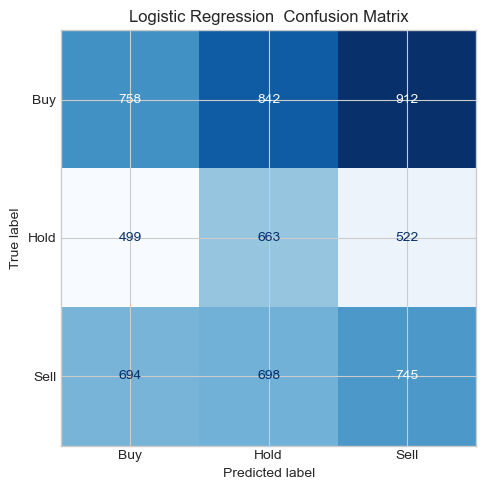

In [8]:
cm = confusion_matrix(res['Actual'], res['Predicted'], labels=['Buy', 'Hold', 'Sell'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Buy', 'Hold', 'Sell'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression  Confusion Matrix')
plt.tight_layout()
plt.show()

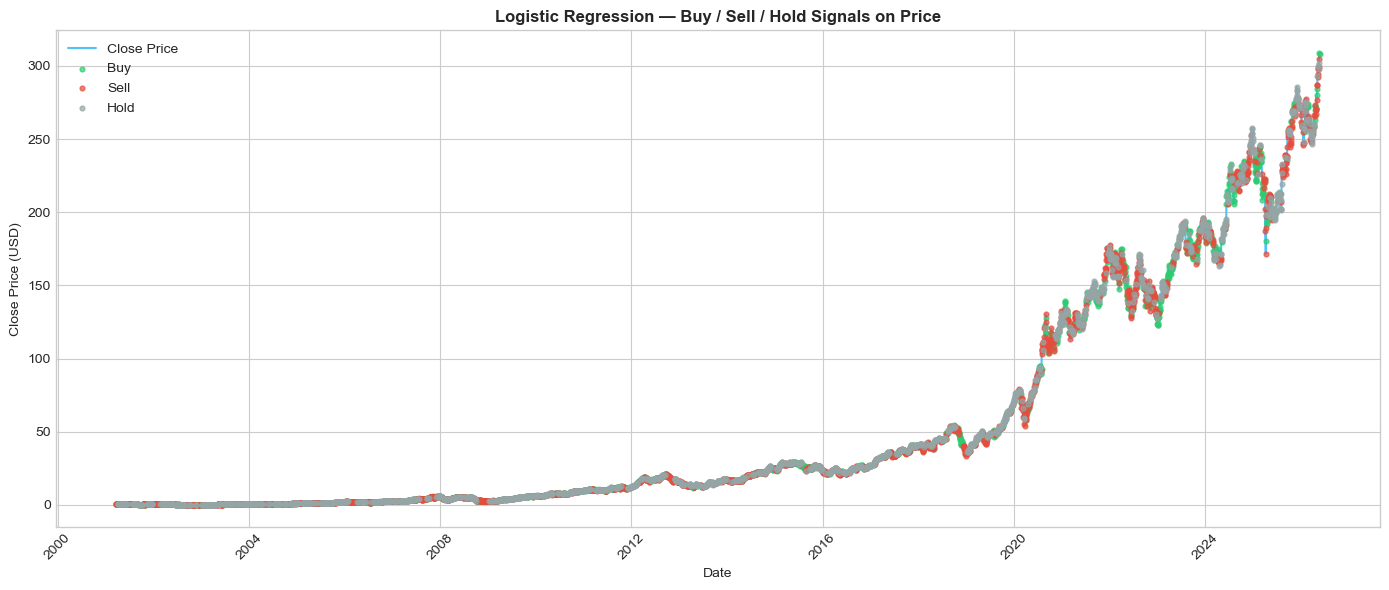

In [9]:
# Plot signals on price chart
color_map = {'Buy': '#2ecc71', 'Sell': '#e74c3c', 'Hold': '#95a5a6'}

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(res['Date'], res['Close'], color='#4fc3f7', linewidth=1.5, label='Close Price', zorder=1)

for signal, color in color_map.items():
    mask = res['Predicted'] == signal
    ax.scatter(res.loc[mask, 'Date'], res.loc[mask, 'Close'], color=color, s=12, label=signal, zorder=2, alpha=0.7)


ax.set_title('Logistic Regression — Buy / Sell / Hold Signals on Price', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (USD)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### A small demo(next day forecast) with Logistic Regression:
(5/27/2026 is not in our dataset)

In [11]:
# Next-day signal forecast
X_final = df[features].values[-window:]
y_final = df['Signal'].values[-window:]

model_final = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=0)),
])

model_final.fit(X_final, y_final)

latest = df[features].iloc[[-1]]
pred_signal = model_final.predict(latest)[0]
pred_proba = model_final.predict_proba(latest)[0]
classes = model_final.classes_
last_date = df['Date'].iloc[-1].date()
next_date = last_date + pd.Timedelta(days=1)

print("=" * 50)
print(f"  NEXT DAY SIGNAL  (from {last_date})")
print(f"  Predicting for:  {next_date}")
print("=" * 50)
print(f"  Signal: {pred_signal}")
print()
print("  Probabilities:")
for c, p in zip(classes, pred_proba):
    print(f"    {c:4s}: {p*100}%")

  NEXT DAY SIGNAL  (from 2026-05-26)
  Predicting for:  2026-05-27
  Signal: Buy

  Probabilities:
    Buy : 42.62555816683823%
    Hold: 27.95319514959146%
    Sell: 29.421246683570303%


/Users/AdamYE_1/opt/anaconda3/envs/ecs171_ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/AdamYE_1/opt/anaconda3/envs/ecs171_ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


# Random Forest Solution:

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay)

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
df = pd.read_csv('APPLE_daily_reformed.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

for col in ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')


df = df.dropna().reset_index(drop=True)
print(f"Rows : {len(df):,}")
print(f"Range: {df['Date'].min().date()} -> {df['Date'].max().date()}")

Rows : 6,638
Range: 2000-01-03 -> 2026-05-26


In [3]:
def add_features(df):
    d = df.copy()
    d['Return_1d'] = d['Close'].pct_change()
    d['Return_2d'] = d['Close'].pct_change(2)
    d['Return_5d'] = d['Close'].pct_change(5)
    d['Return_10d'] = d['Close'].pct_change(10)
    d['Return_20d'] = d['Close'].pct_change(20)

    d['MA_5'] = d['Close'].rolling(5).mean()
    d['MA_20'] = d['Close'].rolling(20).mean()
    d['MA_50'] = d['Close'].rolling(50).mean()
    d['Price_vs_MA5']  = d['Close'] / d['MA_5']  - 1
    d['Price_vs_MA20'] = d['Close'] / d['MA_20'] - 1
    d['Price_vs_MA50'] = d['Close'] / d['MA_50'] - 1
    d['MA5_vs_MA20'] = d['MA_5']  / d['MA_20'] - 1

    delta = d['Close'].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    d['RSI'] = 100 - 100 / (1 + gain / loss)

    bb_mid = d['Close'].rolling(20).mean()
    bb_std = d['Close'].rolling(20).std()
    d['BB_position'] = (d['Close'] - (bb_mid - 2*bb_std)) / (4 * bb_std)
    d['BB_width'] = (4 * bb_std) / bb_mid

    d['Volatility_10'] = d['Return_1d'].rolling(10).std()
    d['Volatility_20'] = d['Return_1d'].rolling(20).std()
    d['Volume_ratio']= d['Volume'] / d['Volume'].rolling(20).mean()
    d['High_Low_pct'] = (d['High'] - d['Low']) / d['Close']
    d['Open_Close_pct']= (d['Close'] - d['Open']) / d['Open']
    d['Lag1_return'] = d['Return_1d'].shift(1)
    d['Lag2_return'] = d['Return_1d'].shift(2)
    d['Lag5_return'] = d['Return_1d'].shift(5)
    return d

features = [
    'Return_1d','Return_2d','Return_5d','Return_10d','Return_20d',
    'Price_vs_MA5','Price_vs_MA20','Price_vs_MA50','MA5_vs_MA20',
    'RSI','BB_position','BB_width',
    'Volatility_10','Volatility_20','Volume_ratio',
    'High_Low_pct','Open_Close_pct',
    'Lag1_return','Lag2_return','Lag5_return',
]

THRESHOLD = 0.005  # 0.5%

def label_signal(ret):
    if ret > THRESHOLD:
        return 'Buy'
    elif ret < -THRESHOLD:
        return 'Sell'
    else:
        return 'Hold'

df = add_features(df)
df['Next_Return'] = df['Close'].pct_change().shift(-1)
df['Signal'] = df['Next_Return'].apply(label_signal)
df = df.dropna(subset=features + ['Signal']).reset_index(drop=True)


print(f'{len(df):,} usable rows | {len(features)} features')
print(df['Signal'].value_counts())
print(f'First prediction date: {df["Date"].iloc[256].date()}')

6,589 usable rows | 20 features
Signal
Buy     2622
Sell    2259
Hold    1708
Name: count, dtype: int64
First prediction date: 2001-03-20


In [4]:
window = 256
retrain_every = 10

X = df[features].values
y = df['Signal'].values
dates  = df['Date'].values
closes = df['Close'].values

results = []
clf = None

print(f"Walk-forward: {len(df)-window:,} predictions to make...")



for i in range(window, len(df)):
    step = i - window

    if step % retrain_every == 0:
        clf = RandomForestClassifier(
            n_estimators=100,
            max_depth=8,
            min_samples_leaf=5,
            class_weight='balanced',  # handles class imbalance
            random_state=0,
            n_jobs=-1
        )
        clf.fit(X[i-window:i], y[i-window:i])

        if step % 500 == 0:
            print(f"  Step {step:,}/{len(df)-window:,}  ({step/(len(df)-window)*100:}%)")

    pred_signal = clf.predict(X[i].reshape(1, -1))[0]
    pred_proba  = clf.predict_proba(X[i].reshape(1, -1))[0]
    classes     = clf.classes_

    results.append({
        'Date':      pd.Timestamp(dates[i]),
        'Close':     closes[i],
        'Actual':    y[i],
        'Predicted': pred_signal,
        **{f'P_{c}': p for c, p in zip(classes, pred_proba)}
    })

res = pd.DataFrame(results)
print(f"\nDone!")
res.tail(8)

Walk-forward: 6,333 predictions to make...
  Step 0/6,333  (0.0%)
  Step 500/6,333  (7.8951523764408655%)
  Step 1,000/6,333  (15.790304752881731%)
  Step 1,500/6,333  (23.685457129322597%)
  Step 2,000/6,333  (31.580609505763462%)
  Step 2,500/6,333  (39.475761882204324%)
  Step 3,000/6,333  (47.37091425864519%)
  Step 3,500/6,333  (55.266066635086055%)
  Step 4,000/6,333  (63.161219011526924%)
  Step 4,500/6,333  (71.05637138796779%)
  Step 5,000/6,333  (78.95152376440865%)
  Step 5,500/6,333  (86.84667614084952%)
  Step 6,000/6,333  (94.74182851729039%)

Done!


,Date,Close,Actual,Predicted,P_Buy,P_Hold,P_Sell
6325,2026-05-14,298.209991,Buy,Sell,0.180575,0.375968,0.443457
6326,2026-05-15,300.230011,Sell,Sell,0.217273,0.367975,0.414753
6327,2026-05-18,297.839996,Hold,Hold,0.157657,0.427277,0.415066
6328,2026-05-19,298.970001,Buy,Sell,0.241862,0.310808,0.447330
6329,2026-05-20,302.250000,Buy,Sell,0.137037,0.399373,0.463589
6330,2026-05-21,304.989990,Buy,Buy,0.347089,0.323205,0.329705
6331,2026-05-22,308.820007,Hold,Buy,0.339644,0.321611,0.338745
6332,2026-05-26,308.329987,Hold,Buy,0.364268,0.322406,0.313327


In [5]:
acc = accuracy_score(res['Actual'], res['Predicted'])
print(f"Overall Accuracy: {acc*100}%")
print()
print(classification_report(res['Actual'], res['Predicted'], target_names=['Buy', 'Hold', 'Sell']))

Overall Accuracy: 37.12300647402495%

              precision    recall  f1-score   support

         Buy       0.41      0.43      0.42      2512
        Hold       0.32      0.27      0.29      1684
        Sell       0.36      0.38      0.37      2137

    accuracy                           0.37      6333
   macro avg       0.36      0.36      0.36      6333
weighted avg       0.37      0.37      0.37      6333



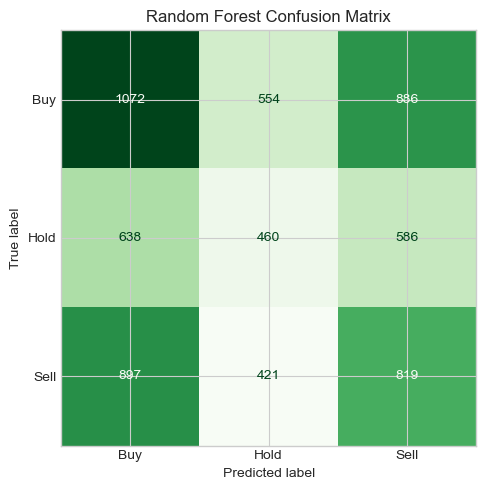

In [6]:

cm = confusion_matrix(res['Actual'], res['Predicted'], labels=['Buy', 'Hold', 'Sell'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Buy', 'Hold', 'Sell'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()

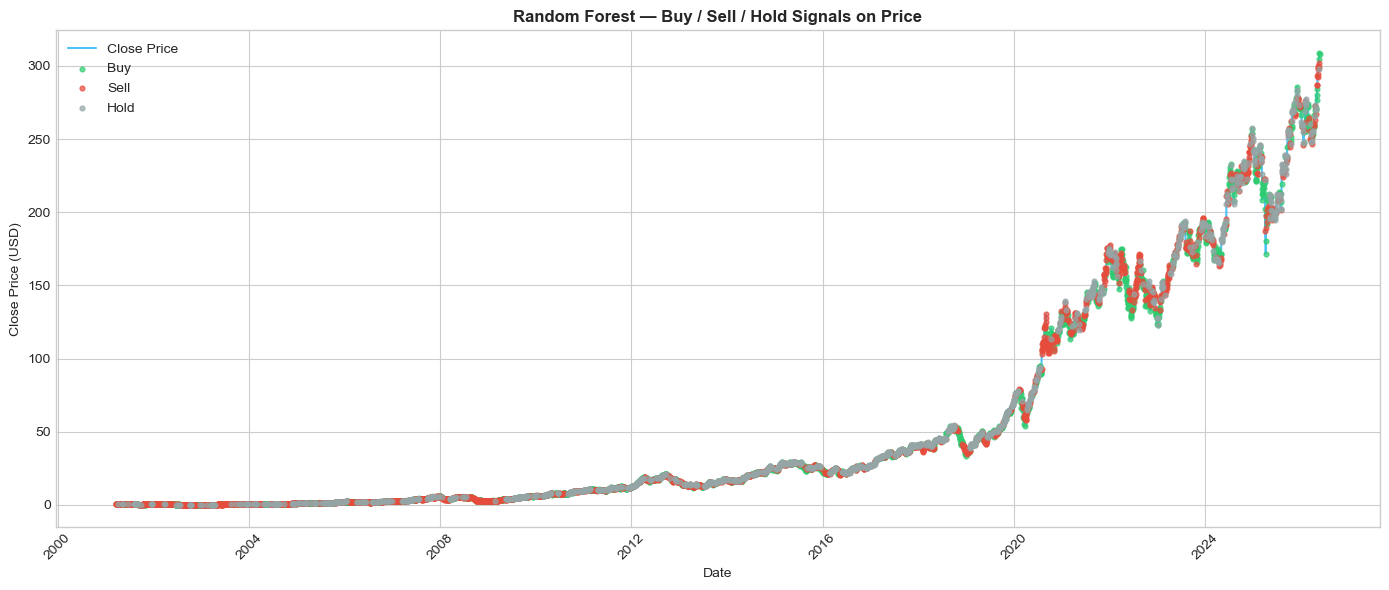

In [7]:
color_map = {'Buy': '#2ecc71', 'Sell': '#e74c3c', 'Hold': '#95a5a6'}

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(res['Date'], res['Close'], color='#4fc3f7', linewidth=1.5, label='Close Price', zorder=1)


for signal, color in color_map.items():
    mask = res['Predicted'] == signal
    ax.scatter(res.loc[mask, 'Date'], res.loc[mask, 'Close'], color=color, s=12, label=signal, zorder=2, alpha=0.7)

ax.set_title('Random Forest — Buy / Sell / Hold Signals on Price', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (USD)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Next day demo with Random Forest:
(5/27/2026 is not in dataset)

In [8]:
X_final = df[features].values[-window:]
y_final = df['Signal'].values[-window:]

clf_final = RandomForestClassifier(
    n_estimators=200, max_depth=8,
    min_samples_leaf=5, class_weight='balanced',
    random_state=0, n_jobs=-1
)

clf_final.fit(X_final, y_final)

latest = df[features].iloc[[-1]]
pred_signal = clf_final.predict(latest)[0]
pred_proba = clf_final.predict_proba(latest)[0]
classes = clf_final.classes_
last_date = df['Date'].iloc[-1].date()
next_date = last_date + pd.Timedelta(days=1)

print("=" * 50)
print(f"  NEXT DAY SIGNAL  (from {last_date})")
print(f"  Predicting for:  {next_date}")
print("=" * 50)
print(f"  Signal: {pred_signal}")
print()
print("  Probabilities:")
for c, p in zip(classes, pred_proba):
    print(f"    {c:4s}: {p*100}%")

  NEXT DAY SIGNAL  (from 2026-05-26)
  Predicting for:  2026-05-27
  Signal: Hold

  Probabilities:
    Buy : 30.861477706117817%
    Hold: 48.84488281157798%
    Sell: 20.293639482304222%


/Users/AdamYE_1/opt/anaconda3/envs/ecs171_ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Users/AdamYE_1/opt/anaconda3/envs/ecs171_ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
